In [1]:
# Importing the Libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from nltk.sentiment.vader import SentimentIntensityAnalyzer
from wordcloud import WordCloud, STOPWORDS, ImageColorGenerator

In [3]:
# Loading the Dataset
data = pd.read_csv('Pfizer Vaccine Sentiment Analysis.csv')

In [5]:
# Analyse the Top 5 rows of the Data
data.head()

,id,user_name,user_location,user_description,user_created,user_followers,user_friends,user_favourites,user_verified,date,text,hashtags,source,retweets,favorites,is_retweet
0,1340539111971516416,Rachel Roh,"La Crescenta-Montrose, CA",Aggregator of Asian American news; scanning di...,2009-04-08 17:52:46,405,1692,3247,False,2020-12-20 06:06:44,Same folks said daikon paste could treat a cyt...,['PfizerBioNTech'],Twitter for Android,0,0,False
1,1338158543359250433,Albert Fong,"San Francisco, CA","Marketing dude, tech geek, heavy metal & '80s ...",2009-09-21 15:27:30,834,666,178,False,2020-12-13 16:27:13,While the world has been on the wrong side of ...,NaN,Twitter Web App,1,1,False
2,1337858199140118533,eli🇱🇹🇪🇺👌,Your Bed,"heil, hydra 🖐☺",2020-06-25 23:30:28,10,88,155,False,2020-12-12 20:33:45,#coronavirus #SputnikV #AstraZeneca #PfizerBio...,"['coronavirus', 'SputnikV', 'AstraZeneca', 'Pf...",Twitter for Android,0,0,False
3,1337855739918835717,Charles Adler,"Vancouver, BC - Canada","Hosting ""CharlesAdlerTonight"" Global News Radi...",2008-09-10 11:28:53,49165,3933,21853,True,2020-12-12 20:23:59,"Facts are immutable, Senator, even when you're...",NaN,Twitter Web App,446,2129,False
4,1337854064604966912,Citizen News Channel,NaN,Citizen News Channel bringing you an alternati...,2020-04-23 17:58:42,152,580,1473,False,2020-12-12 20:17:19,Explain to me again why we need a vaccine @Bor...,"['whereareallthesickpeople', 'PfizerBioNTech']",Twitter for iPhone,0,0,False


In [7]:
# Now let’s have a look at whether it contains any null values
data.isnull().sum()

id                     0
user_name              0
user_location       1630
user_description     507
user_created           0
user_followers         0
user_friends           0
user_favourites        0
user_verified          0
date                   0
text                   0
hashtags            1949
source                 1
retweets               0
favorites              0
is_retweet             0
dtype: int64

##### Although these null values will not affect the task of sentiment analysis, to keep things simple, we will drop the rows containing null values as the dataset is already large

In [10]:
data = data.dropna()

In [12]:
# Now let’s have a look at the descriptive statistics
data.describe()

,id,user_followers,user_friends,user_favourites,retweets,favorites
count,4.749000e+03,4.749000e+03,4749.000000,4749.000000,4749.000000,4749.000000
mean,1.355333e+18,5.069683e+04,1341.396926,14523.124447,1.545378,9.385555
std,1.280104e+16,3.545440e+05,3453.847283,36379.651961,13.395572,55.280915
min,1.337728e+18,0.000000e+00,0.000000,0.000000,0.000000,0.000000
25%,1.344929e+18,1.740000e+02,215.000000,497.000000,0.000000,0.000000
50%,1.352030e+18,6.480000e+02,549.000000,2713.000000,0.000000,1.000000
75%,1.364940e+18,2.728000e+03,1419.000000,12258.000000,1.000000,5.000000
max,1.384788e+18,1.371493e+07,103226.000000,854011.000000,678.000000,1979.000000


In [14]:
import nltk
import re
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\irt\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [16]:
stemmer = nltk.SnowballStemmer("english")


In [18]:
from nltk.corpus import stopwords
import string

In [20]:
stopword=set(stopwords.words('english'))


In [24]:
def clean(text):
    text = str(text).lower()
    text = re.sub('\[.*?\]', '', text)
    text = re.sub('https?://\S+|www\.\S+', '', text)
    text = re.sub('<.*?>+', '', text)
    text = re.sub('[%s]' % re.escape(string.punctuation), '', text)
    text = re.sub('\n', '', text)
    text = re.sub('\w*\d\w*', '', text)
    text = [word for word in text.split(' ') if word not in stopword]
    text=" ".join(text)
    text = [stemmer.stem(word) for word in text.split(' ')]
    text=" ".join(text)
    return text
    data["text"] = data["text"].apply(clean)

<>:3: SyntaxWarning: invalid escape sequence '\['
<>:4: SyntaxWarning: invalid escape sequence '\S'
<>:8: SyntaxWarning: invalid escape sequence '\w'
<>:3: SyntaxWarning: invalid escape sequence '\['
<>:4: SyntaxWarning: invalid escape sequence '\S'
<>:8: SyntaxWarning: invalid escape sequence '\w'
C:\Users\irt\AppData\Local\Temp\ipykernel_17188\956538697.py:3: SyntaxWarning: invalid escape sequence '\['
  text = re.sub('\[.*?\]', '', text)
C:\Users\irt\AppData\Local\Temp\ipykernel_17188\956538697.py:4: SyntaxWarning: invalid escape sequence '\S'
  text = re.sub('https?://\S+|www\.\S+', '', text)
C:\Users\irt\AppData\Local\Temp\ipykernel_17188\956538697.py:8: SyntaxWarning: invalid escape sequence '\w'
  text = re.sub('\w*\d\w*', '', text)


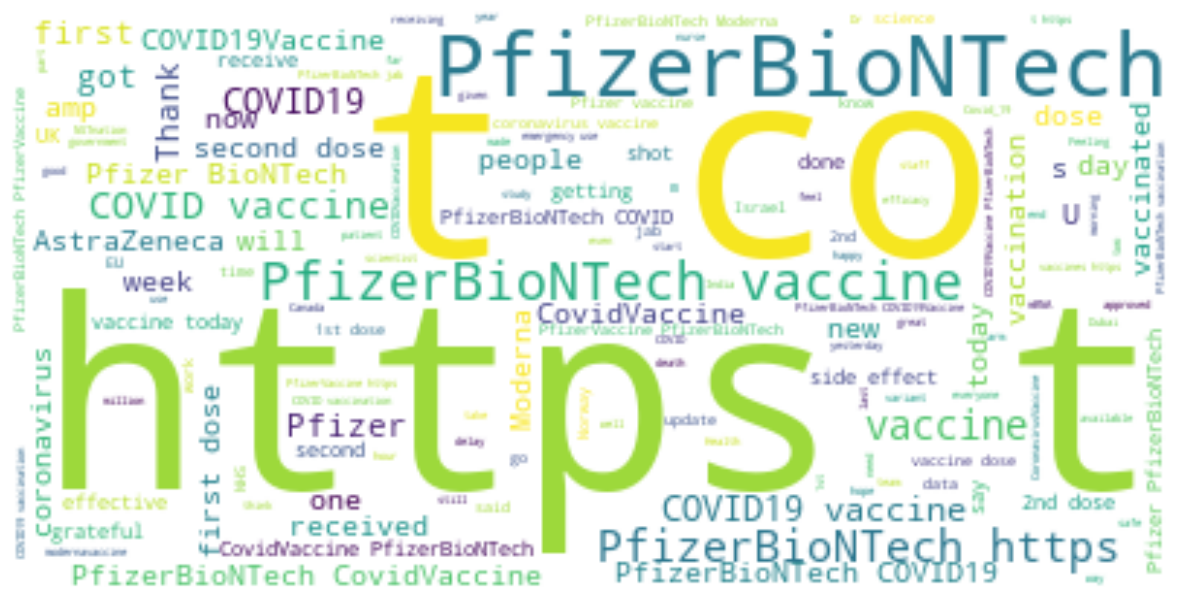

In [26]:
text = " ".join(i for i in data.text)
stopwords = set(STOPWORDS)
wordcloud = WordCloud(stopwords=stopwords, background_color="white").generate(text)
plt.figure( figsize=(15,10))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.show()

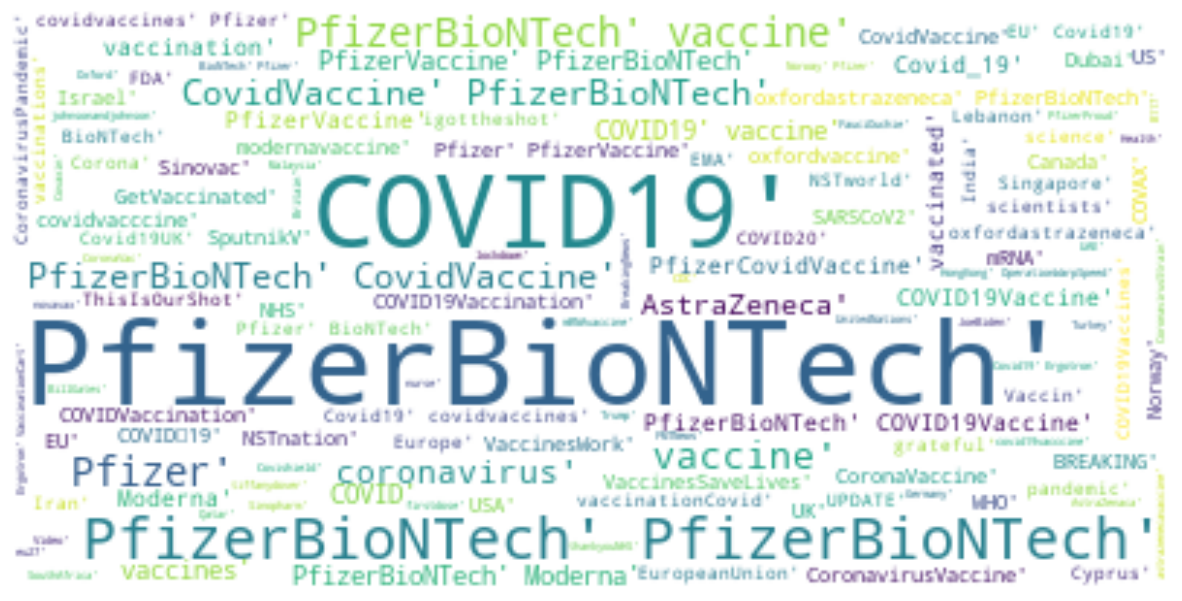

In [28]:
text = " ".join(i for i in data.hashtags)
stopwords = set(STOPWORDS)
wordcloud = WordCloud(stopwords=stopwords, background_color="white").generate(text)
plt.figure( figsize=(15,10))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.show()

##### The “user_verified” column in the dataset shows whether the users who have shared their opinions are verified by Twitter or not. A verified user on Twitter is a public figure or a celebrity.

In [31]:
# So let’s have a look at how many users were verified who shared their opinions about the Pfizer vaccine
data["user_verified"].value_counts()

user_verified
False    4169
True      580
Name: count, dtype: int64

In [33]:
nltk.download('vader_lexicon')
sentiments = SentimentIntensityAnalyzer()
data["Positive"] = [sentiments.polarity_scores(i)["pos"] for i in data["text"]]
data["Negative"] = [sentiments.polarity_scores(i)["neg"] for i in data["text"]]
data["Neutral"] = [sentiments.polarity_scores(i)["neu"] for i in data["text"]]
data = data[["text", "Positive", "Negative", "Neutral"]]
print(data.head())

[nltk_data] Downloading package vader_lexicon to
[nltk_data]     C:\Users\irt\AppData\Roaming\nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


                                                 text  Positive  Negative  \
0   Same folks said daikon paste could treat a cyt...     0.213     0.000   
2   #coronavirus #SputnikV #AstraZeneca #PfizerBio...     0.125     0.000   
6   it is a bit sad to claim the fame for success ...     0.238     0.112   
9   #CovidVaccine \n\nStates will start getting #C...     0.000     0.000   
10  while deaths are closing in on the 300,000 mar...     0.000     0.000   

    Neutral  
0     0.787  
2     0.875  
6     0.650  
9     1.000  
10    1.000  


In [45]:
x = sum(data["Positive"])
y = sum(data["Negative"])
z = sum(data["Neutral"])
def sentiment_score(a, b, c):
    if (a>b) and (a>c):
        print("Positive 😊 ")
    elif (b>a) and (b>c):
        print("Negative 😠 ")
    else:
        print("Neutral 🙂 ")
sentiment_score(x, y, z)

Neutral 🙂 


In [47]:
print("Positive: ", x)
print("Negative: ", y)
print("Neutral: ", z)

Positive:  416.124
Negative:  166.625
Neutral:  4166.24


##### The total of positive and negative is very less than Neutral, so we can say that the discussion of the Twitter users was about the awareness of the Pfizer vaccine rather than sharing its benefits or drawbacks.

#### Summary

In the conclusion of this sentiment analysis, I can just say that the discussion of the Twitter users was about the awareness of the Pfizer vaccine rather than sharing its benefits or drawbacks. 